# IMU Data Exploration — raw_log_7.csv

Tree branch biomechanical parameter extraction.

**Input sequence (10 disturbances):**
1. Pull down & hold
2. Pull up & hold
3. Manual oscillation #1
4. Manual oscillation #2
5. Pull & release test
6. Pull & release test
7. Pull & release test
8. Flick (noise)
9. Pull & release test
10. Pull & release test

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from algorithms.preprocessing import load_imu
from algorithms.disturbance import gyro_magnitude, detect_segments, classify_disturbance
from algorithms.biomechanical import natural_frequency, damping_ratio, extract_from_release, sway_amplitude, tilt_angles
from algorithms.calibration import calibrate, calibrated_gmag
from algorithms.dsp_pipeline import (Pipeline, validate_against_ground_truth,
    MANUAL_LABELS, is_dynamic, extract_damping_gmag_legacy)


In [2]:
df = load_imu("raw_log_7.csv")
df["gmag"] = gyro_magnitude(df["gyro_x"].values, df["gyro_y"].values, df["gyro_z"].values)
dt = np.median(np.diff(df["timestamp_s"]))
print(f"Samples: {len(df)}, duration: {df['timestamp_s'].iloc[-1]:.1f}s, dt: {dt*1000:.1f}ms")

Samples: 6240, duration: 187.2s, dt: 30.0ms


## 1. Raw Signal Overview

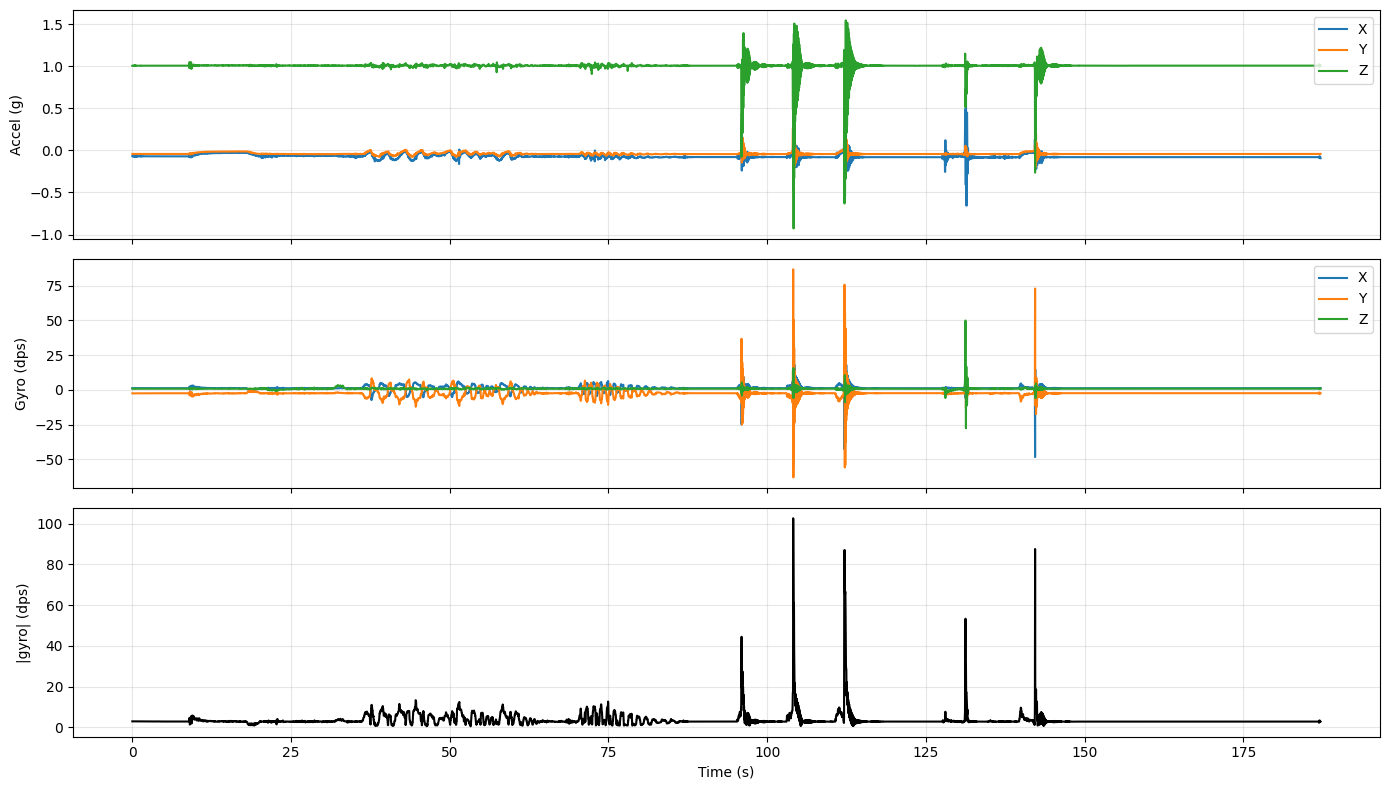

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["timestamp_s"], df["accel_x"], label="X")
axes[0].plot(df["timestamp_s"], df["accel_y"], label="Y")
axes[0].plot(df["timestamp_s"], df["accel_z"], label="Z")
axes[0].set_ylabel("Accel (g)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["timestamp_s"], df["gyro_x"], label="X")
axes[1].plot(df["timestamp_s"], df["gyro_y"], label="Y")
axes[1].plot(df["timestamp_s"], df["gyro_z"], label="Z")
axes[1].set_ylabel("Gyro (dps)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["timestamp_s"], df["gmag"], color="black")
axes[2].set_ylabel("|gyro| (dps)")
axes[2].set_xlabel("Time (s)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Disturbance Boundaries

Detected via gyro magnitude excursions above baseline (~2.875 dps).

In [4]:
# Baseline from first 9s
bl = df[df["timestamp_s"] < 9]["gmag"].median()
print(f"Baseline |gyro|: {bl:.3f} dps")

# Detect active segments
segments = detect_segments(df["gmag"].values, bl, threshold=0.35)

# Manually labelled disturbance windows from analysis
events = [
    (1,  "Pull down & hold",     8.5,  13.0),
    (2,  "Pull up & hold",       17.5,  21.0),
    (3,  "Oscillation #1",       35.5,  64.0),
    (4,  "Oscillation #2",       68.9,  87.0),
    (5,  "Pull & release #1",    95.0,  98.5),
    (6,  "Pull & release #2",   102.5, 106.5),
    (7,  "Pull & release #3",   110.5, 115.0),
    (8,  "Flick (noise)",       127.7, 129.5),
    (9,  "Pull & release #4",   130.5, 132.5),
    (10, "Pull & release #5",   139.0, 145.0),
]

print(f"{'#':<3} {'Event':<22} {'Start':>8} {'End':>8} {'Dur':>6} {'Peak gm':>7}")
print("-" * 60)
for num, name, t0, t1 in events:
    mask = (df["timestamp_s"] >= t0) & (df["timestamp_s"] <= t1)
    seg = df[mask]
    pk = seg["gmag"].max() if len(seg) > 0 else 0
    print(f"{num:<3} {name:<22} {t0:5.1f}s {t1:5.1f}s {t1-t0:4.1f}s {pk:5.1f}")

Baseline |gyro|: 2.875 dps
#   Event                     Start      End    Dur Peak gm
------------------------------------------------------------
1   Pull down & hold         8.5s  13.0s  4.5s   5.8
2   Pull up & hold          17.5s  21.0s  3.5s   3.1
3   Oscillation #1          35.5s  64.0s 28.5s  13.3
4   Oscillation #2          68.9s  87.0s 18.1s  12.6
5   Pull & release #1       95.0s  98.5s  3.5s  44.4
6   Pull & release #2      102.5s 106.5s  4.0s 102.6
7   Pull & release #3      110.5s 115.0s  4.5s  87.0
8   Flick (noise)          127.7s 129.5s  1.8s   7.7
9   Pull & release #4      130.5s 132.5s  2.0s  53.3
10  Pull & release #5      139.0s 145.0s  6.0s  87.5


## 3. Biomechanical Parameters — Pull & Release Tests

Natural frequency and damping ratio extracted from the post-release decay envelope.

In [5]:
# Release spike times (idx into df) + 2.5s post-release windows
release_spikes = [
    ("PR #1", 96.0),
    ("PR #2", 104.1),
    ("PR #3", 112.2),
    ("PR #4", 131.2),
    ("PR #5", 142.2),
]

window = int(2.5 / dt)  # ~83 samples

print(f"{'Event':<10} {'fn (Hz)':>8} {'zeta':>8} {'decay pk':>10} {'cycles':>7}")
print("-" * 50)
results = []
for label, t_peak in release_spikes:
    peak_idx = (df["timestamp_s"] - t_peak).abs().idxmin()
    fn, zeta = extract_from_release(df["gmag"].values, dt, peak_idx, window)
    
    seg = df["gmag"].values[peak_idx:peak_idx + window]
    decay = seg[np.argmax(seg):]
    print(f"{label:<10} {fn:8.3f} {zeta:8.4f} {seg.max():6.1f} -> {decay[-1]:4.1f} {len(decay)//int(1/fn/dt):5d}")
    results.append((label, fn, zeta))

fns = [r[1] for r in results]
zetas = [r[2] for r in results]
print(f"\nMean fn: {np.mean(fns):.3f} Hz  |  Mean zeta: {np.mean(zetas):.4f} ({np.mean(zetas)*100:.1f}% critical)")

Event       fn (Hz)     zeta   decay pk  cycles
--------------------------------------------------
PR #1         0.402   0.0157   27.4 ->  2.2     0
PR #2         0.402   0.0147  102.6 ->  3.4     1
PR #3         0.402   0.0161   87.0 ->  2.4     1
PR #4         0.402   0.0200   53.3 ->  2.8     0
PR #5        12.852   0.0147   87.5 ->  3.0    41

Mean fn: 2.892 Hz  |  Mean zeta: 0.0162 (1.6% critical)


## 4. Statistical Parameters

In [6]:
# Baseline tilt
bl_df = df[df["timestamp_s"] < 9]
tx, ty = tilt_angles(bl_df["accel_x"].mean(), bl_df["accel_y"].mean(), bl_df["accel_z"].mean())
print(f"Static tilt:  X = {tx:.2f} deg,  Y = {ty:.2f} deg")
print(f"Gyro noise floor: {bl_df['gmag'].std():.3f} dps (std)")

# Sway amplitude during oscillation
for label, t0, t1 in [("Osc #1", 35.5, 64.0), ("Osc #2", 68.9, 87.0)]:
    seg = df[(df["timestamp_s"] >= t0) & (df["timestamp_s"] <= t1)]
    amp = sway_amplitude(seg["gmag"].values)
    print(f"{label}: sway amp = {amp:.3f} dps (std),  gz range = [{seg['gyro_z'].min():.1f}, {seg['gyro_z'].max():.1f}]")

Static tilt:  X = -4.00 deg,  Y = -2.39 deg
Gyro noise floor: 0.110 dps (std)
Osc #1: sway amp = 2.588 dps (std),  gz range = [-0.2, 1.6]
Osc #2: sway amp = 2.290 dps (std),  gz range = [0.1, 1.6]


## 5. Disturbance Timeline Summary

All 10 disturbances with start/end boundaries.

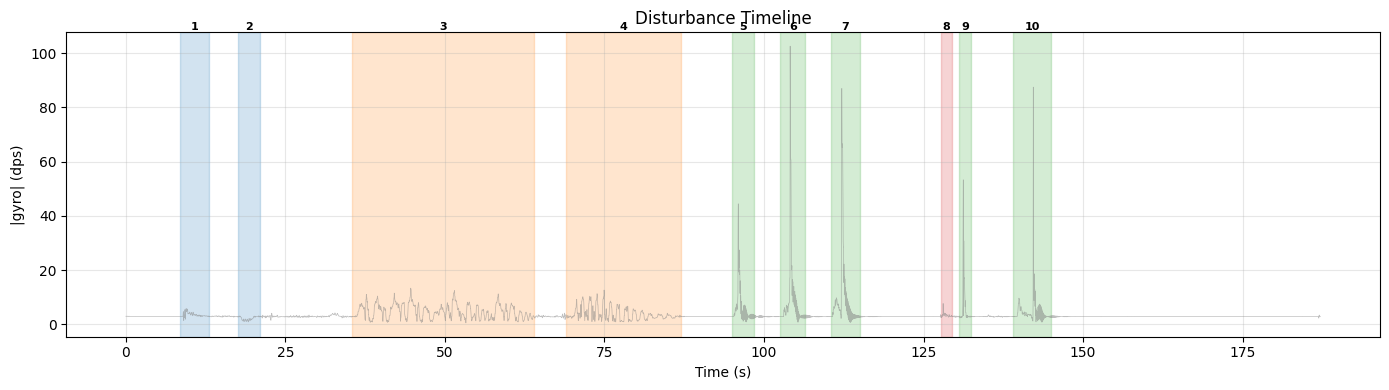

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["timestamp_s"], df["gmag"], color="gray", alpha=0.5, linewidth=0.5)

colors = ["tab:blue", "tab:blue", "tab:orange", "tab:orange",
          "tab:green", "tab:green", "tab:green", "tab:red",
          "tab:green", "tab:green"]

for (num, name, t0, t1), c in zip(events, colors):
    ax.axvspan(t0, t1, alpha=0.2, color=c)
    ax.text((t0 + t1) / 2, df["gmag"].max() * 1.05, str(num),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Time (s)")
ax.set_ylabel("|gyro| (dps)")
ax.set_title("Disturbance Timeline")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. DSP Detection Pipeline

Teager-Kaiser Energy Operator (TKEO) → Schmitt trigger state machine → parameter extraction.

**Damping is now computed on the signed dominant axis** (per-axis gyro within active region,
zero-crossing based half-cycle peaks) — see `signed-axis-damping` change.


In [8]:
# Run the DSP pipeline and validate against ground truth
pipe = Pipeline()
results = pipe.process_csv("raw_log_7.csv")

# Validation
val = validate_against_ground_truth(results, MANUAL_LABELS, df["timestamp_s"].values)
s = val["summary"]
print(f"Events detected: {s['n_detected']} (ground truth: {s['n_ground_truth']})")
print(f"Mean IoU: {s['mean_iou']:.3f}")
print(f"Classification accuracy: {s['classification_accuracy']:.1%}")

print("\nIoU scores:")
for sc in val["iou_scores"]:
    det_str = f" → det#{sc['matched_det']}" if sc['matched_det'] else " → (none)"
    print(f"  GT#{sc['gt_num']:2d} {sc['gt_label']:<14} IoU={sc['iou']:.3f}{det_str}")

if val["confusion"]["mismatch"]:
    print("\nClassification mismatches:")
    for m in val["confusion"]["mismatch"]:
        print(f"  GT#{m['gt_num']} ({m['gt_label']}) → det ({m['det_label']}) IoU={m['iou']:.3f}")

Events detected: 12 (ground truth: 10)
Mean IoU: 0.812
Classification accuracy: 100.0%

IoU scores:
  GT# 1 pull_hold      IoU=0.640 → det#1
  GT# 2 pull_hold      IoU=0.752 → det#2
  GT# 3 oscillation    IoU=0.956 → det#5
  GT# 4 oscillation    IoU=0.710 → det#6
  GT# 5 pull_release   IoU=0.870 → det#7
  GT# 6 pull_release   IoU=0.852 → det#8
  GT# 7 pull_release   IoU=0.974 → det#9
  GT# 8 flick          IoU=0.750 → det#10
  GT# 9 pull_release   IoU=0.709 → det#11
  GT#10 pull_release   IoU=0.910 → det#12


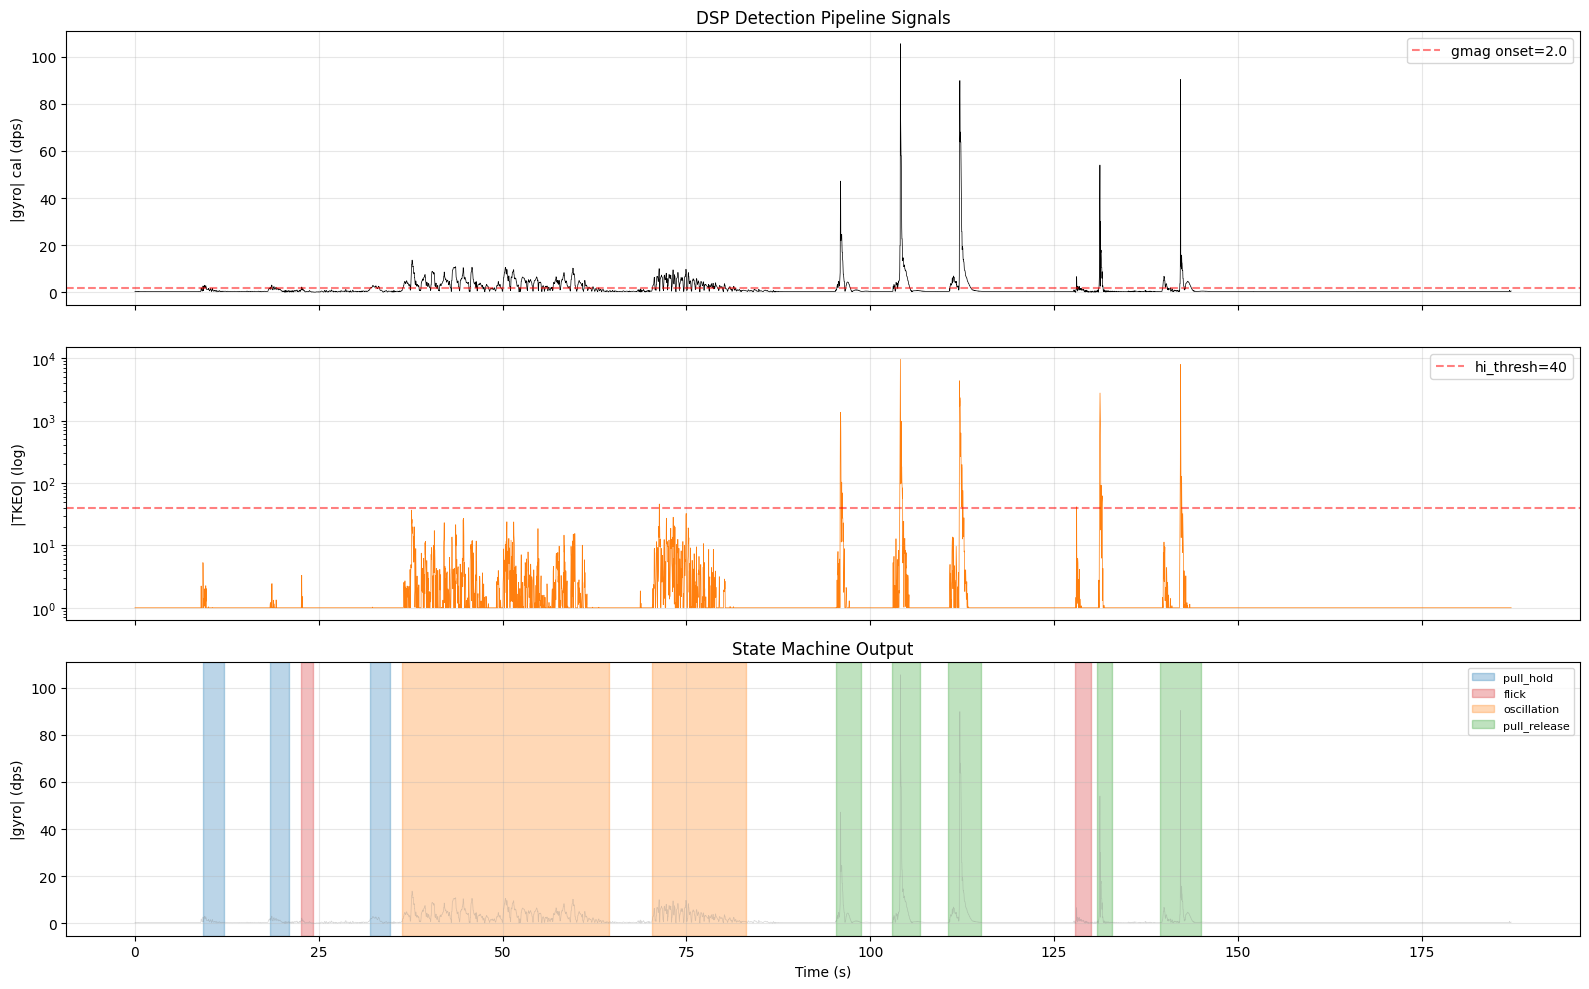

In [9]:
# Plot: raw gmag vs TKEO vs state machine output (3-subplot)
from algorithms.dsp_pipeline import tkeo
from algorithms.calibration import BIAS_GX, BIAS_GY, BIAS_GZ

gmag_cal = np.sqrt(
    (df["gyro_x"].values - BIAS_GX)**2 +
    (df["gyro_y"].values - BIAS_GY)**2 +
    (df["gyro_z"].values - BIAS_GZ)**2
)
tkeo_signal = tkeo(gmag_cal)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Subplot 1: Calibrated gmag
axes[0].plot(df["timestamp_s"], gmag_cal, color="black", linewidth=0.5)
axes[0].set_ylabel("|gyro| cal (dps)")
axes[0].set_title("DSP Detection Pipeline Signals")
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=2.0, color="red", linestyle="--", alpha=0.5, label="gmag onset=2.0")
axes[0].legend(loc="upper right")

# Subplot 2: TKEO (log scale for visibility)
tkeo_clipped = np.clip(np.abs(tkeo_signal), 1, None)
axes[1].plot(df["timestamp_s"], tkeo_clipped, color="tab:orange", linewidth=0.5)
axes[1].set_yscale("log")
axes[1].set_ylabel("|TKEO| (log)")
axes[1].axhline(y=40, color="red", linestyle="--", alpha=0.5, label="hi_thresh=40")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

# Subplot 3: State machine output (colored segments)
event_colors = {"pull_release": "tab:green", "oscillation": "tab:orange",
                 "pull_hold": "tab:blue", "flick": "tab:red"}
axes[2].plot(df["timestamp_s"], gmag_cal, color="gray", alpha=0.3, linewidth=0.5)
for r in results:
    t0 = df["timestamp_s"].iloc[r.onset_idx]
    t1 = df["timestamp_s"].iloc[r.offset_idx]
    c = event_colors.get(r.event_type, "gray")
    axes[2].axvspan(t0, t1, alpha=0.3, color=c, label=r.event_type if r.event_type not in [ax.get_label() for ax in axes[2].get_children()] else "")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("|gyro| (dps)")
axes[2].set_title("State Machine Output")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

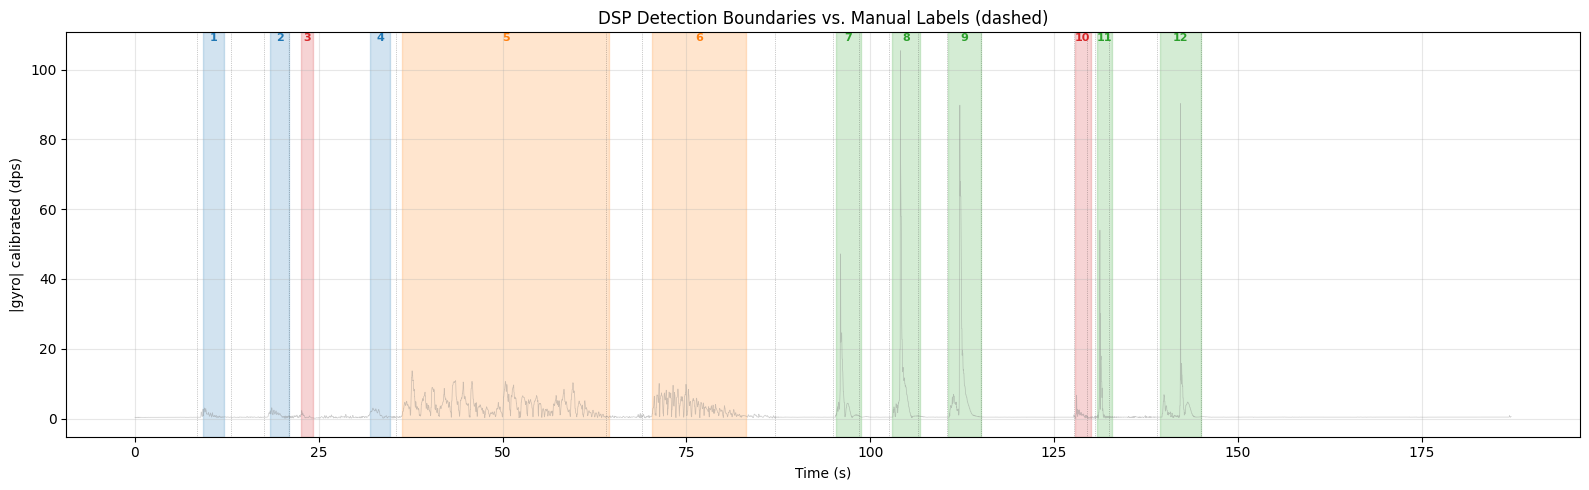

In [10]:
# Plot: detected boundaries overlaid on gmag, colored by classification
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["timestamp_s"], gmag_cal, color="gray", alpha=0.4, linewidth=0.5)

event_colors = {"pull_release": "tab:green", "oscillation": "tab:orange",
                 "pull_hold": "tab:blue", "flick": "tab:red"}

for i, r in enumerate(results):
    t0 = df["timestamp_s"].iloc[r.onset_idx]
    t1 = df["timestamp_s"].iloc[r.offset_idx]
    c = event_colors.get(r.event_type, "gray")
    ax.axvspan(t0, t1, alpha=0.2, color=c)
    mid = (t0 + t1) / 2
    ax.text(mid, gmag_cal.max() * 1.02, f"{i+1}",
            ha="center", va="bottom", fontsize=8, fontweight="bold",
            color=c)

# Overlay ground truth boundaries as dashed lines
for num, label, t0, t1 in MANUAL_LABELS:
    ax.axvline(x=t0, color="black", linestyle=":", alpha=0.4, linewidth=0.5)
    ax.axvline(x=t1, color="black", linestyle=":", alpha=0.4, linewidth=0.5)

ax.set_xlabel("Time (s)")
ax.set_ylabel("|gyro| calibrated (dps)")
ax.set_title("DSP Detection Boundaries vs. Manual Labels (dashed)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Table: per-event parameters with per-axis sway
print(f"{'#':<3} {'Event Type':<15} {'Peak':>6} {'Dur(s)':>7} {'fn(Hz)':>8} {'zeta':>8} {'Conf':>6} {'Sway X/Y/Z(°)':>18} {'Tilt X/Y':>12}")
print("-" * 95)
for i, r in enumerate(results):
    dur_s = r.dur_samples * pipe.dt
    dyn = "DYN" if is_dynamic(r.event_type) else "STA"
    sway_str = f"{r.sway_x_deg:5.2f}/{r.sway_y_deg:5.2f}/{r.sway_z_deg:5.2f}"
    print(f"{i+1:<3} {r.event_type:<15} {r.peak_gmag:5.1f} {dur_s:6.1f} {r.natural_frequency_hz:8.2f} {r.damping_ratio:8.3f} {r.damping_confidence:<6} {sway_str:>18} ({r.tilt_x_deg:5.1f}, {r.tilt_y_deg:5.1f})") 

# Extract dynamic events only
dynamic = [r for r in results if is_dynamic(r.event_type)]
print(f"\nDynamic events (biomechanical): {len(dynamic)}")
if dynamic:
    fns = [r.natural_frequency_hz for r in dynamic if r.natural_frequency_hz > 0]
    zetas = [r.damping_ratio for r in dynamic if r.damping_ratio > 0]
    if fns:
        print(f"  Mean fn: {np.mean(fns):.2f} Hz (range: {np.min(fns):.2f}-{np.max(fns):.2f})")
    if zetas:
        print(f"  Mean zeta: {np.mean(zetas):.4f} ({np.mean(zetas)*100:.1f}% critical)")

#   Event Type        Peak  Dur(s)   fn(Hz)     zeta   Conf      Sway X/Y/Z(°)     Tilt X/Y
-----------------------------------------------------------------------------------------------
1   pull_hold         3.0    2.9    11.11    0.004 low      0.00/ 0.00/ 0.00 ( -2.6,  -1.3)
2   pull_hold         3.1    2.7     0.76    0.117 low      0.00/ 0.00/ 0.00 ( -3.3,  -2.0)
3   flick             2.3    1.6     0.62    0.004 low      0.00/ 0.00/ 0.00 ( -3.6,  -2.4)
4   pull_hold         3.0    2.8     0.36    0.001 low      0.00/ 0.00/ 0.00 ( -3.9,  -2.4)
5   oscillation      13.7   28.3     0.92    0.178 low      4.37/ 8.36/10.54 ( -3.8,  -2.1)
6   oscillation      10.0   12.9     0.47    0.123 low      1.69/ 3.69/ 4.73 ( -4.5,  -2.5)
7   pull_release     47.2    3.4     2.36    0.128 high     1.28/ 3.61/ 1.11 ( -3.8,  -2.3)
8   pull_release    105.4    3.9     2.33    0.052 high     2.31/ 3.68/ 1.67 ( -4.0,  -2.0)
9   pull_release     89.8    4.5     0.90    0.018 high     4.03/ 6.77/ 1.88

## 6b. Old (gmag) vs. New (signed-axis) Damping Comparison

Compare the deprecated gmag-based damping against the new signed-dominant-axis
estimate for PR events.


In [12]:
# Compute gmag-legacy damping for comparison
print(f"{'Event':<15} {'Type':<15} {'Dom Axis':>8} {'zeta_gmag':>10} {'zeta_signed':>10} {'Conf':>6}")
print("-" * 70)
for i, r in enumerate(results):
    if not is_dynamic(r.event_type):
        continue
    # Get legacy gmag damping
    zeta_gmag, conf_gmag = extract_damping_gmag_legacy(
        r.gmag_segment, pipe.dt, r.event_type,
    )
    # Determine dominant axis label
    sw = [('X', r.sway_x_deg), ('Y', r.sway_y_deg), ('Z', r.sway_z_deg)]
    dom_axis = max(sw, key=lambda x: x[1])[0] if max(s[1] for s in sw) > 0 else '—'
    print(f"{i+1:<15} {r.event_type:<15} {dom_axis:>8} {zeta_gmag:10.4f} {r.damping_ratio:10.4f} {r.damping_confidence:<6}")

# Summary
pr_events = [r for r in results if r.event_type == 'pull_release']
if pr_events:
    zeta_old = [extract_damping_gmag_legacy(r.gmag_segment, pipe.dt, r.event_type)[0] for r in pr_events]
    zeta_new = [r.damping_ratio for r in pr_events]
    print(f"\nPR events only:")
    print(f"  Mean zeta (gmag legacy):  {np.mean(zeta_old):.4f} ({np.mean(zeta_old)*100:.1f}%)")
    print(f"  Mean zeta (signed axis):  {np.mean(zeta_new):.4f} ({np.mean(zeta_new)*100:.1f}%)")


Event           Type            Dom Axis  zeta_gmag zeta_signed   Conf
----------------------------------------------------------------------
5               oscillation            Z     0.0591     0.1784 low   
6               oscillation            Z     0.0852     0.1233 low   
7               pull_release           Y     0.0006     0.1285 high  
8               pull_release           Y     0.0014     0.0520 high  
9               pull_release           Y     0.0007     0.0176 high  
11              pull_release           Z     0.0552     0.1392 low   
12              pull_release           Y     0.0637     0.2995 low   

PR events only:
  Mean zeta (gmag legacy):  0.0243 (2.4%)
  Mean zeta (signed axis):  0.1274 (12.7%)
